In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
# ---------------------------------------------------
# 1. Load Dataset
# ---------------------------------------------------

data = pd.read_csv("data/boston_housing(1).csv")

print("Dataset Shape:", data.shape)
print(data.head())

Dataset Shape: (506, 14)
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [5]:
display(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


None

In [6]:
display(data.describe())

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [7]:
display(data.shape)

(506, 14)

In [8]:
data.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [9]:
df = data.copy()

In [10]:
Q1 = df["MEDV"].quantile(0.25)
Q3 = df["MEDV"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_no_outliers = df[(df["MEDV"] >= lower_bound) & (df["MEDV"] <= upper_bound)]

In [11]:
df_no_outliers.size

6524

In [12]:
# ---------------------------------------------------
# 2. Split Features and Target
# ---------------------------------------------------

X = df_no_outliers.drop("MEDV", axis=1)
y = df_no_outliers["MEDV"]            # Target Output (House Price)

In [13]:

# ---------------------------------------------------
# 3. Train-Test Split
# ---------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (372, 13)
Testing Samples: (94, 13)


In [14]:

# ---------------------------------------------------
# 4. Feature Scaling (Very Important for DNN)
# ---------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [15]:

# ---------------------------------------------------
# 5. Build Deep Neural Network Regression Model
# ---------------------------------------------------

model = Sequential()

# Input Layer + Hidden Layer 1
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))

# Hidden Layer 2
model.add(Dense(32, activation='relu'))

# Hidden Layer 3
model.add(Dense(16, activation='relu'))

# Output Layer (Linear Regression Output)
model.add(Dense(1))  # No activation → Linear Regression


In [16]:
# ---------------------------------------------------
# 6. Compile Model
# ---------------------------------------------------

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)


In [17]:
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

In [18]:
# ---------------------------------------------------
# 7. Train Model
# ---------------------------------------------------

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
19/19 [==============================] - 2s 14ms/step - loss: 471.5904 - mae: 20.6999 - val_loss: 413.4437 - val_mae: 19.3309
Epoch 2/200
19/19 [==============================] - 0s 4ms/step - loss: 416.0863 - mae: 19.2953 - val_loss: 345.7797 - val_mae: 17.4888
Epoch 3/200
19/19 [==============================] - 0s 8ms/step - loss: 323.3484 - mae: 16.6518 - val_loss: 228.2607 - val_mae: 13.7487
Epoch 4/200
19/19 [==============================] - 0s 3ms/step - loss: 177.0387 - mae: 11.9159 - val_loss: 86.6412 - val_mae: 8.2077
Epoch 5/200
19/19 [==============================] - 0s 5ms/step - loss: 57.5030 - mae: 6.2928 - val_loss: 36.6661 - val_mae: 5.0645
Epoch 6/200
19/19 [==============================] - 2s 104ms/step - loss: 33.7889 - mae: 4.6417 - val_loss: 23.6378 - val_mae: 4.0048
Epoch 7/200
19/19 [==============================] - 0s 3ms/step - loss: 23.8196 - mae: 3.8583 - val_loss: 17.5790 - val_mae: 3.4092
Epoch 8/200
19/19 [==============================] -

3/3 [==============================] - 0s 2ms/step

Model Performance:
Mean Squared Error: 5.167677004967036
Mean Absolute Error: 1.7660249121645661
Root Mean Squared Error: 2.273252516762499
R2 Score: 0.8711799123966845


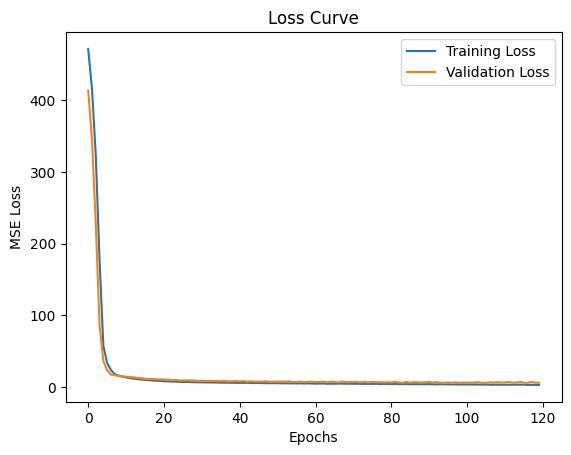

In [19]:

# ---------------------------------------------------
# 8. Evaluate Model
# ---------------------------------------------------

y_pred = model.predict(X_test)

# Performance Metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

# ---------------------------------------------------
# 9. Plot Training Loss
# ---------------------------------------------------

plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

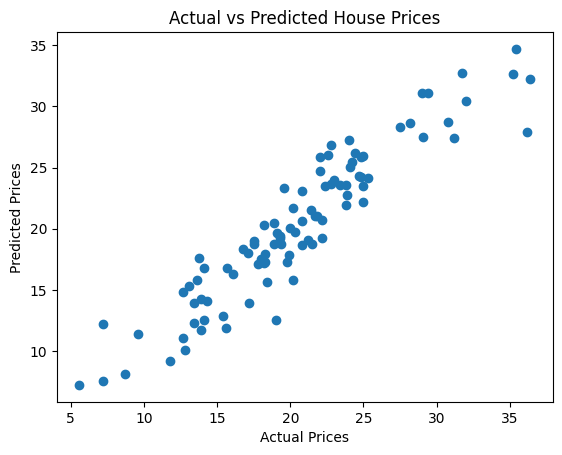

In [20]:
# ---------------------------------------------------
# 10. Actual vs Predicted Plot
# ---------------------------------------------------

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()